In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Passband:1.00 dB
Stopband:15.00 dB
解出 Butterworth 濾波器階數 N = 6

--- (1) Butterworth 數位系統函數 H(z) 係數 ---
分子多項式 B(z) 係數: [8.88178420e-16-9.43689571e-16j 6.30960857e-04+2.77555756e-15j
 1.01034590e-02-3.44169138e-15j 1.61433512e-02+2.44249065e-15j
 4.10068044e-03-6.66133815e-16j 1.03251535e-04+1.11022302e-16j]
分母多項式 A(z) 係數: [ 1.        +0.00000000e+00j -3.36352172+0.00000000e+00j
  5.0684257 -1.11022302e-16j -4.27587051+0.00000000e+00j
  2.10662435-2.22044605e-16j -0.57065044+0.00000000e+00j
  0.06607444+0.00000000e+00j]


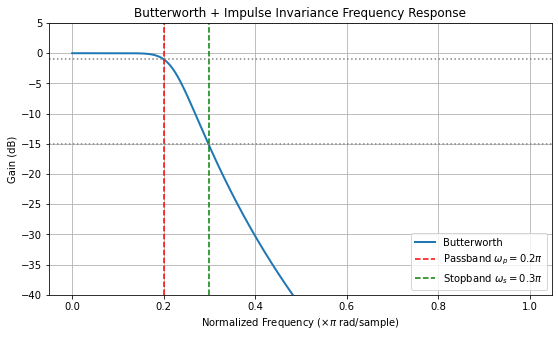

In [ ]:
# 1. 填入規格參數
wp = 0.2 * np.pi
ws = 0.3 * np.pi
Rp = -20 * np.log10(0.89125)   # 通帶衰減 1 dB
Rs = -20 * np.log10(0.17783)   # 阻帶衰減 15 dB
T = 1.0  # 預設抽樣週期

print(f"Passband:{Rp:.2f} dB")
print(f"Stopband:{Rs:.2f} dB")

# 2. 脈衝響應不變法的類比頻率映射 (Omega = omega / T)
Omega_p = wp / T
Omega_s = ws / T

# 3. 計算類比 Butterworth 濾波器的最小階數 N 與 3dB 截止頻率 Wn
N, Wn = signal.buttord(Omega_p, Omega_s, Rp, Rs, analog=True)
print(f"解出 Butterworth 濾波器階數 N = {N}")

# 4. 產生類比濾波器的傳遞函數 H_a(s) = b / a
b_analog, a_analog = signal.butter(N, Wn, analog=True)

# 5. 使用部分分式展開法 (Residue) 手動實現脈衝響應不變法轉換
r, p, k = signal.residue(b_analog, a_analog)
p_digital = np.exp(p * T)  # 極點映射: z = e^(sT)
r_digital = r * T          # 增益修正
bz_butt, az_butt = signal.invresz(r_digital, p_digital, k)

print("\n--- (1) Butterworth 數位系統函數 H(z) 係數 ---")
print("分子多項式 B(z) 係數:", bz_butt)
print("分母多項式 A(z) 係數:", az_butt)

# 6. 計算並繪製頻率響應
w_axis, h_butt = signal.freqz(bz_butt, az_butt, worN=512)

plt.figure(figsize=(9, 5))
plt.plot(w_axis / np.pi, 20 * np.log10(np.abs(h_butt)), label='Butterworth', linewidth=2)
plt.axvline(0.2, color='r', linestyle='--', label=r'Passband $\omega_p = 0.2\pi$')
plt.axvline(0.3, color='g', linestyle='--', label=r'Stopband $\omega_s = 0.3\pi$')
plt.axhline(-1, color='gray', linestyle=':')
plt.axhline(-15, color='gray', linestyle=':')
plt.title("Butterworth + Impulse Invariance Frequency Response")
plt.xlabel(r"Normalized Frequency ($\times \pi$ rad/sample)")
plt.ylabel("Gain (dB)")
plt.ylim([-40, 5])
plt.grid(True)
plt.legend()
plt.show()

解出 Chebyshev 濾波器階數 N = 4

--- (2) Chebyshev 數位系統函數 H(z) 係數 ---
分子多項式 B(z) 係數: [0.00183554 0.00734217 0.01101326 0.00734217 0.00183554]
分母多項式 A(z) 係數: [ 1.         -3.0543415   3.82900339 -2.29245526  0.55074561]


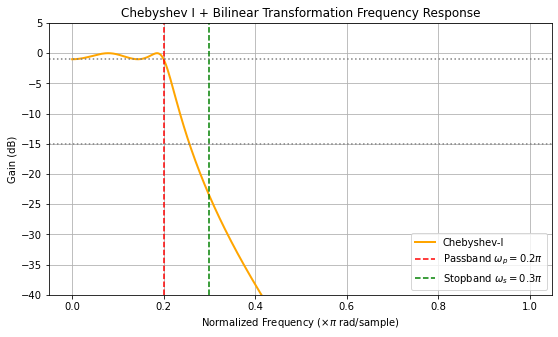

In [ ]:
# 1. 雙線性轉換法的類比頻率預扭曲 (Pre-warping)
Omega_p_bl = (2 / T) * np.tan(wp / 2)
Omega_s_bl = (2 / T) * np.tan(ws / 2)

# 2. 計算類比 Chebyshev I 型濾波器的最小階數 與 截止頻率
N_ch, Wn_ch = signal.cheb1ord(Omega_p_bl, Omega_s_bl, Rp, Rs, analog=True)
print(f"解出 Chebyshev 濾波器階數 N = {N_ch}")

# 3. 產生類比 Chebyshev I 型濾波器 H_a(s)
b_an_ch, a_an_ch = signal.cheby1(N_ch, Rp, Wn_ch, analog=True)

# 4. 使用雙線性轉換法轉成數位濾波器 H(z)
bz_ch, az_ch = signal.bilinear(b_an_ch, a_an_ch, fs=1/T)

print("\n--- (2) Chebyshev 數位系統函數 H(z) 係數 ---")
print("分子多項式 B(z) 係數:", bz_ch)
print("分母多項式 A(z) 係數:", az_ch)

# 5. 計算並繪製頻率響應
w_axis_ch, h_ch = signal.freqz(bz_ch, az_ch, worN=512)

plt.figure(figsize=(9, 5))
plt.plot(w_axis_ch / np.pi, 20 * np.log10(np.abs(h_ch)), label='Chebyshev-I', color='orange', linewidth=2)
plt.axvline(0.2, color='r', linestyle='--', label=r'Passband $\omega_p = 0.2\pi$')
plt.axvline(0.3, color='g', linestyle='--', label=r'Stopband $\omega_s = 0.3\pi$')
plt.axhline(-1, color='gray', linestyle=':')
plt.axhline(-15, color='gray', linestyle=':')
plt.title("Chebyshev I + Bilinear Transformation Frequency Response")
plt.xlabel(r"Normalized Frequency ($\times \pi$ rad/sample)")
plt.ylabel("Gain (dB)")
plt.ylim([-40, 5])
plt.grid(True)
plt.legend()
plt.show()

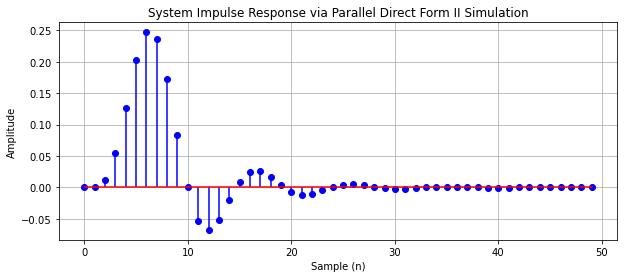

In [ ]:
def parallel_df2_filter(x):
    """
    自訂並聯 Direct Form II 濾波器
    x: 輸入訊號序列
    """
    N = len(x)
    y = np.zeros(N)
    
    # 初始化三個子系統的延遲暫存器 (每個系統需要 2 個狀態空間)
    # w1[0] 對應 w1[n-1], w1[1] 對應 w1[n-2]
    w1 = np.zeros(2)
    w2 = np.zeros(2)
    w3 = np.zeros(2)
    
    # 逐點處理訊號 (時域模擬)
    for n in range(N):
        xn = x[n]
        
        # --- 子系統 1 狀態更新與輸出 ---
        # 分母回授 (注意變號): w1[n] = x[n] - a1*w1[n-1] - a2*w1[n-2]
        w1_new = xn - (-1.2971)*w1[0] - (0.6949)*w1[1]
        # 分子前向: y1[n] = b0*w1[n] + b1*w1[n-1]
        y1 = 0.2871*w1_new + (-0.4466)*w1[0]
        
        # --- 子系統 2 狀態更新與輸出 ---
        w2_new = xn - (-1.0691)*w2[0] - (0.3699)*w2[1]
        y2 = -2.1428*w2_new + 1.1455*w2[0]
        
        # --- 子系統 3 狀態更新與輸出 ---
        w3_new = xn - (-0.9972)*w3[0] - (0.2570)*w3[1]
        y3 = 1.8557*w3_new + (-0.6303)*w3[0]
        
        # 總輸出為三個並聯分支相加
        y[n] = y1 + y2 + y3
        
        # 移位更新暫存器狀態，準備下一個時間點
        w1[1], w1[0] = w1[0], w1_new
        w2[1], w2[0] = w2[0], w2_new
        w3[1], w3[0] = w3[0], w3_new
        
    return y

# --- 測試與驗證程式碼 ---
if __name__ == "__main__":
    # 建立一個簡單的測試訊號 (例如單位脈衝訊號，用來觀測脈衝響應)
    delta_input = np.zeros(50)
    delta_input[0] = 1.0
    
    # 執行濾波器
    output_y = parallel_df2_filter(delta_input)
    
    # 繪製模擬結果
    plt.figure(figsize=(10, 4))
    plt.stem(output_y, linefmt='b-', markerfmt='bo', basefmt='r-')
    plt.title("System Impulse Response via Parallel Direct Form II Simulation")
    plt.xlabel("Sample (n)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

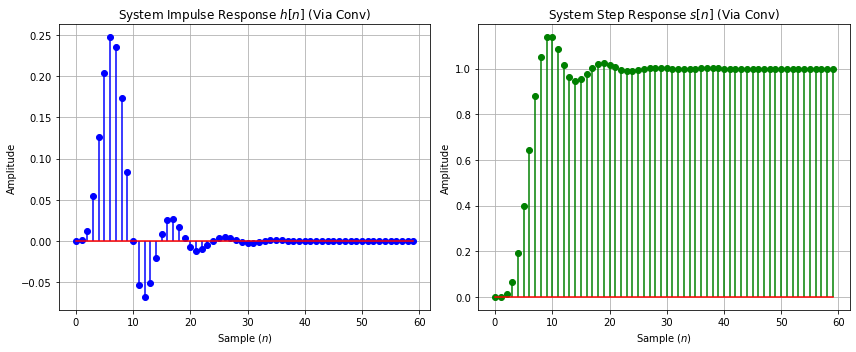

In [ ]:
# 1. 定義三個分支的原始分子與分母
b1 = np.array([0.2871, -0.4466, 0.0])
a1 = np.array([1.0, -1.2971, 0.6949])

b2 = np.array([-2.1428, 1.1455, 0.0])
a2 = np.array([1.0, -1.0691, 0.3699])

b3 = np.array([1.8557, -0.6303, 0.0])
a3 = np.array([1.0, -0.9972, 0.2570])

# 2. 通分計算總系統函數：H = (b1*a2*a3 + b2*a1*a3 + b3*a1*a2) / (a1*a2*a3)
B_total = np.convolve(b1, np.convolve(a2, a3)) + \
          np.convolve(b2, np.convolve(a1, a3)) + \
          np.convolve(b3, np.convolve(a1, a2))

A_total = np.convolve(a1, np.convolve(a2, a3))

# 3. 設定模擬的資料點數（觀察前 60 點的響應）
num_points = 60
n = np.arange(num_points)

# 建立單位脈衝輸入 delta[n] 與單位階梯輸入 u[n]
delta_input = np.zeros(num_points)
delta_input[0] = 1.0

step_input = np.ones(num_points)

# 4. 利用通分後的系統係數進行時域模擬
impulse_response = signal.lfilter(B_total, A_total, delta_input)
step_response = signal.lfilter(B_total, A_total, step_input)

# 5. 繪製系統響應圖
plt.figure(figsize=(12, 5))

# (1) 單位脈衝響應圖 (Impulse Response)
plt.subplot(1, 2, 1)
plt.stem(n, impulse_response, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title("System Impulse Response $h[n]$ (Via Conv)")
plt.xlabel("Sample ($n$)")
plt.ylabel("Amplitude")
plt.grid(True)

# (2) 單位階梯響應圖 (Step Response)
plt.subplot(1, 2, 2)
plt.stem(n, step_response, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title("System Step Response $s[n]$ (Via Conv)")
plt.xlabel("Sample ($n$)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

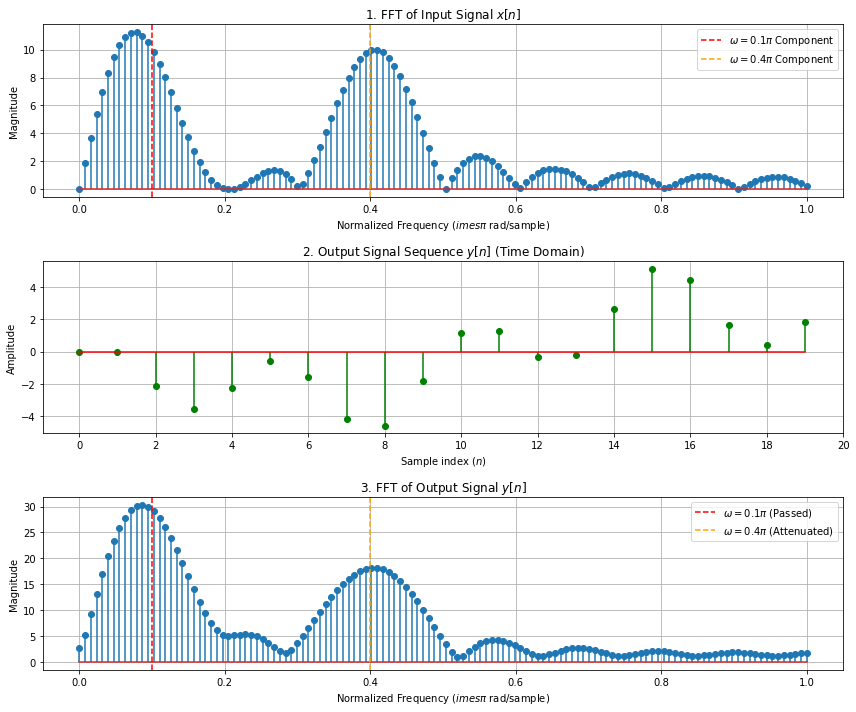

In [ ]:
# ==========================================
# 1. 延續第二題：定義並聯濾波器係數並通分
# ==========================================
b1 = np.array([0.2871, -0.4466, 0.0])
a1 = np.array([1.0, -1.2971, 0.6949])

b2 = np.array([-2.1428, 1.1455, 0.0])
a2 = np.array([1.0, -1.0691, 0.3699])

b3 = np.array([1.8557, -0.6303, 0.0])
a3 = np.array([1.0, -0.09972, 0.2570])

# 進行多項式相乘(卷積)通分
B_total = np.convolve(b1, np.convolve(a2, a3)) + \
          np.convolve(b2, np.convolve(a1, a3)) + \
          np.convolve(b3, np.convolve(a1, a2))

A_total = np.convolve(a1, np.convolve(a2, a3))

# ==========================================
# 2. 設計輸入訊號 (20個資料點，包含 0.1*pi 與 0.4*pi)
# ==========================================
n = np.arange(20)  # n = 0, 1, ..., 19
# 設計包含兩個頻率成分的訊號
x = np.sin(0.1 * np.pi * n) + np.sin(0.4 * np.pi * n)

# ==========================================
# 3. 計算輸出結果 (通過系統模擬)
# ==========================================
y = signal.lfilter(B_total, A_total, x)

# ==========================================
# 4. 頻域分析 (FFT 計算)
# ==========================================
# 為了讓 20 點的訊號在頻譜圖上呈現流暢的曲線（而非只有幾個零散的點），
# 我們在 FFT 時做點數補零（Zero-padding）到 256 點。
N_fft = 256 
X_fft = np.fft.fft(x, N_fft)
Y_fft = np.fft.fft(y, N_fft)

# 建立頻率軸：將頻率歸一化到 0 ~ pi (正半週頻譜)
frequencies = np.linspace(0, 1, N_fft // 2)

# ==========================================
# 5. 繪製題目要求的圖表
# ==========================================
plt.figure(figsize=(12, 10))

# 【圖一】輸入訊號的 FFT 圖
plt.subplot(3, 1, 1)
plt.stem(frequencies, np.abs(X_fft[:N_fft // 2]))
plt.axvline(0.1, color='red', linestyle='--', label='$\omega = 0.1\pi$ Component')
plt.axvline(0.4, color='orange', linestyle='--', label='$\omega = 0.4\pi$ Component')
plt.title("1. FFT of Input Signal $x[n]$", fontsize=12)
plt.xlabel("Normalized Frequency ($\times\pi$ rad/sample)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()

# 【圖二】輸出結果的訊號數字序列圖 (時域 y[n])
plt.subplot(3, 1, 2)
plt.stem(np.arange(len(y)), y, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title("2. Output Signal Sequence $y[n]$ (Time Domain)", fontsize=12)
plt.xlabel("Sample index ($n$)")
plt.ylabel("Amplitude")
plt.xticks(np.arange(0, 21, 2))
plt.grid(True)

# 【圖三】輸出結果的 FFT 圖
plt.subplot(3, 1, 3)
plt.stem(frequencies, np.abs(Y_fft[:N_fft // 2]))
plt.axvline(0.1, color='red', linestyle='--', label='$\omega = 0.1\pi$ (Passed)')
plt.axvline(0.4, color='orange', linestyle='--', label='$\omega = 0.4\pi$ (Attenuated)')
plt.title("3. FFT of Output Signal $y[n]$", fontsize=12)
plt.xlabel("Normalized Frequency ($\times\pi$ rad/sample)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

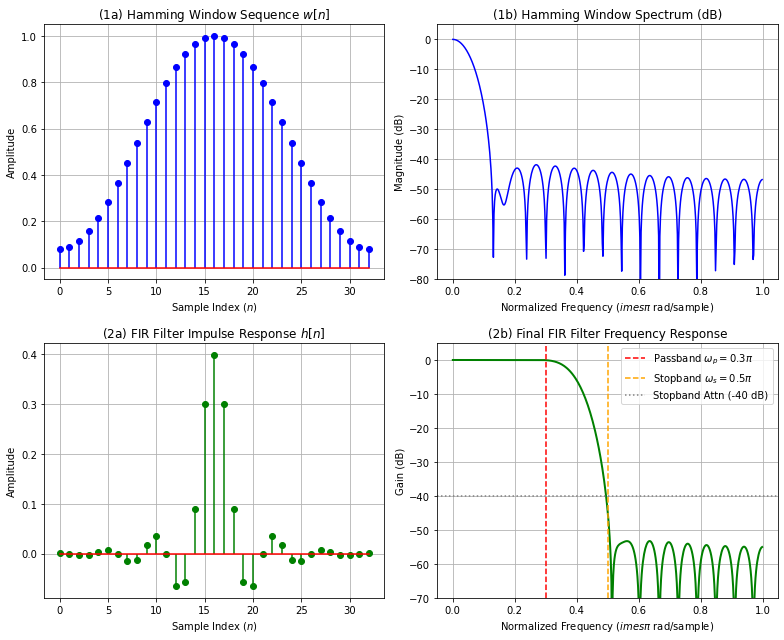

--- FIR 濾波器係數 h[n] ---
[ 1.51234722e-03 -1.38403976e-18 -2.48490347e-03 -2.26515115e-03
  3.34508476e-03  7.82124644e-03 -5.67030460e-18 -1.51321582e-02
 -1.26182068e-02  1.68173737e-02  3.60964201e-02 -1.23942492e-17
 -6.54293674e-02 -5.74814479e-02  9.01953707e-02  2.99795986e-01
  3.99654812e-01  2.99795986e-01  9.01953707e-02 -5.74814479e-02
 -6.54293674e-02 -1.23942492e-17  3.60964201e-02  1.68173737e-02
 -1.26182068e-02 -1.51321582e-02 -5.67030460e-18  7.82124644e-03
  3.34508476e-03 -2.26515115e-03 -2.48490347e-03 -1.38403976e-18
  1.51234722e-03]


In [ ]:
# ==========================================
# 1. 參數定義（根據自訂規格）
# ==========================================
M = 33              # 窗函數長度 (長度為 33 點，對應 32 階 FIR)
omega_c = 0.4       # 理想低通截止頻率 (以 pi 為單位，即 0.4*pi)
wp = 0.3            # 通帶邊界 (0.3*pi)
ws = 0.5            # 阻帶邊界 (0.5*pi)

# ==========================================
# 2. (1) 產生漢明窗並分析其序列與頻率響應
# ==========================================
w_hamming = signal.windows.hamming(M)
w_axis, h_window = signal.freqz(w_hamming, [1], worN=512)

plt.figure(figsize=(11, 9))

# 窗函數時域序列
plt.subplot(2, 2, 1)
plt.stem(w_hamming, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title("(1a) Hamming Window Sequence $w[n]$")
plt.xlabel("Sample Index ($n$)")
plt.ylabel("Amplitude")
plt.grid(True)

# 窗函數頻率響應 (分貝)
plt.subplot(2, 2, 2)
plt.plot(w_axis / np.pi, 20 * np.log10(np.abs(h_window) / np.max(np.abs(h_window))), color='blue')
plt.title("(1b) Hamming Window Spectrum (dB)")
plt.xlabel("Normalized Frequency ($\times\pi$ rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.ylim([-80, 5])
plt.grid(True)

# ==========================================
# 3. (2) 設計 FIR 濾波器並計算其脈衝響應
# ==========================================
# 使用 firwin 函數：指定階數為 M-1，截止頻率為 omega_c，並乘上 hamming 窗
h_fir = signal.firwin(numtaps=M, cutoff=omega_c, window='hamming')

# 計算最終 FIR 濾波器的頻率響應以進行驗證
w_axis_f, h_filter = signal.freqz(h_fir, [1], worN=512)

# FIR 濾波器之脈衝響應序列
plt.subplot(2, 2, 3)
plt.stem(h_fir, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title("(2a) FIR Filter Impulse Response $h[n]$")
plt.xlabel("Sample Index ($n$)")
plt.ylabel("Amplitude")
plt.grid(True)

# 最終 FIR 濾波器的頻率響應圖
plt.subplot(2, 2, 4)
plt.plot(w_axis_f / np.pi, 20 * np.log10(np.abs(h_filter)), color='green', linewidth=2)
# 標記我們自訂的通帶與阻帶邊界線，驗證是否符合規格
plt.axvline(wp, color='red', linestyle='--', label=r'Passband $\omega_p=0.3\pi$')
plt.axvline(ws, color='orange', linestyle='--', label=r'Stopband $\omega_s=0.5\pi$')
plt.axhline(-40, color='gray', linestyle=':', label='Stopband Attn (-40 dB)')
plt.title("(2b) Final FIR Filter Frequency Response")
plt.xlabel("Normalized Frequency ($\times\pi$ rad/sample)")
plt.ylabel("Gain (dB)")
plt.ylim([-70, 5])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("--- FIR 濾波器係數 h[n] ---")
print(h_fir)

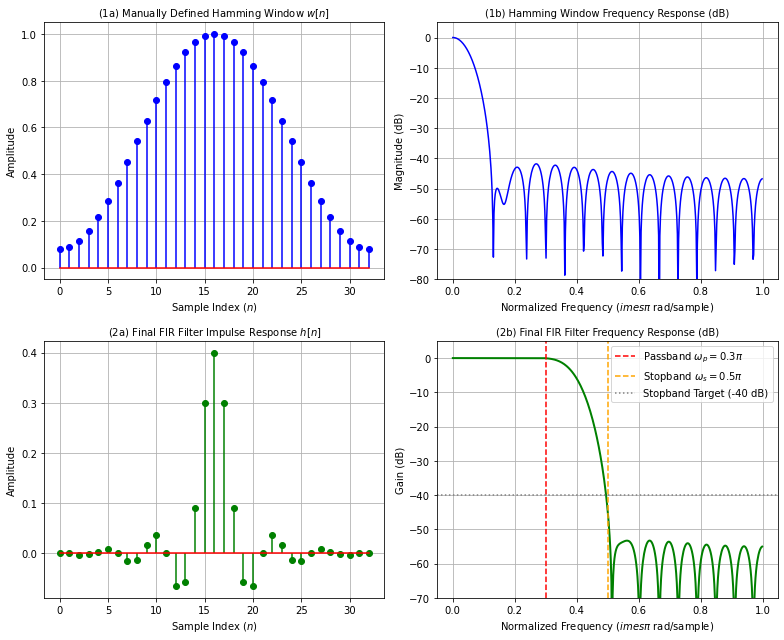

--- 手動產生的窗函數 w[n] 數值 ---
[0.08   0.0888 0.115  0.1575 0.2147 0.2844 0.364  0.4503 0.54   0.6297
 0.716  0.7956 0.8653 0.9225 0.965  0.9912 1.     0.9912 0.965  0.9225
 0.8653 0.7956 0.716  0.6297 0.54   0.4503 0.364  0.2844 0.2147 0.1575
 0.115  0.0888 0.08  ]

--- 手動設計出的 FIR 濾波器脈衝響應 h[n] 數值 ---
[ 0.0015 -0.     -0.0025 -0.0023  0.0033  0.0078 -0.     -0.0151 -0.0126
  0.0168  0.0361 -0.     -0.0655 -0.0575  0.0903  0.3001  0.4     0.3001
  0.0903 -0.0575 -0.0655 -0.      0.0361  0.0168 -0.0126 -0.0151 -0.
  0.0078  0.0033 -0.0023 -0.0025 -0.      0.0015]


In [ ]:
# ==========================================
# 1. 自訂規格填空與參數定義
# ==========================================
# 報告填空規格：
# 0.95 <= |H(e^jw)| <= 1,   |w| <= 0.3*pi
# |H(e^jw)| <= 0.01,       0.5*pi <= |w|
wp = 0.3 * np.pi    # 通帶截止頻率
ws = 0.5 * np.pi    # 阻帶截止頻率
delta_w = ws - wp   # 過渡帶寬度 = 0.2*pi

# 根據 Hamming 窗過渡帶公式估算長度： M ≈ 6.6*pi / delta_w = 6.6*pi / 0.2*pi = 33
M = 33              # 濾波器總長度 (32階 FIR)
alpha = (M - 1) / 2 # 對稱中心點 (alpha = 16)
wc = (wp + ws) / 2  # 理想低通截止頻率 = 0.4*pi

n = np.arange(M)    # 時間軸 n = 0, 1, ..., 32

# ==========================================
# 2. 手動建立「理想低通濾波器」脈衝響應 hd[n]
# ==========================================
# 理想低通公式為 hd[n] = sin(wc * (n - alpha)) / (pi * (n - alpha))
# 注意：當 n = alpha 時分母為 0，此時極限值為 wc / pi
hd = np.zeros(M)
for i in range(M):
    if i == alpha:
        hd[i] = wc / np.pi
    else:
        hd[i] = np.sin(wc * (i - alpha)) / (np.pi * (i - alpha))

# ==========================================
# 3. 手動建立「漢明窗函數」序列 w[n]
# ==========================================
# Hamming Window 數學公式： w[n] = 0.54 - 0.46 * cos(2*pi*n / (M-1))
w_hamming = 0.54 - 0.46 * np.cos(2 * np.pi * n / (M - 1))

# ==========================================
# 4. 手動結合（點對點相乘）得到最終 FIR 濾波器 h[n]
# ==========================================
h_fir = hd * w_hamming

# ==========================================
# 5. 計算頻率響應以供繪圖 (驗證用)
# ==========================================
w_axis, h_window_freq = signal.freqz(w_hamming, [1], worN=512)
w_axis_f, h_filter_freq = signal.freqz(h_fir, [1], worN=512)

# ==========================================
# 6. 繪製題目要求的期末報告圖表
# ==========================================
plt.figure(figsize=(11, 9))

# (1) 滿足規格的窗函數序列 w[n]
plt.subplot(2, 2, 1)
plt.stem(n, w_hamming, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title("(1a) Manually Defined Hamming Window $w[n]$", fontsize=10)
plt.xlabel("Sample Index ($n$)")
plt.ylabel("Amplitude")
plt.grid(True)

# (1) 窗函數的頻率響應圖
plt.subplot(2, 2, 2)
plt.plot(w_axis / np.pi, 20 * np.log10(np.abs(h_window_freq) / np.max(np.abs(h_window_freq))), color='blue')
plt.title("(1b) Hamming Window Frequency Response (dB)", fontsize=10)
plt.xlabel("Normalized Frequency ($\times\pi$ rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.ylim([-80, 5])
plt.grid(True)

# (2) 最終 FIR 濾波器的 impulse response sequence h[n]
plt.subplot(2, 2, 3)
plt.stem(n, h_fir, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title("(2a) Final FIR Filter Impulse Response $h[n]$", fontsize=10)
plt.xlabel("Sample Index ($n$)")
plt.ylabel("Amplitude")
plt.grid(True)

# 最終 FIR 濾波器的頻率響應圖（驗證規格用）
plt.subplot(2, 2, 4)
plt.plot(w_axis_f / np.pi, 20 * np.log10(np.abs(h_filter_freq)), color='green', linewidth=2)
plt.axvline(wp / np.pi, color='red', linestyle='--', label=r'Passband $\omega_p=0.3\pi$')
plt.axvline(ws / np.pi, color='orange', linestyle='--', label=r'Stopband $\omega_s=0.5\pi$')
plt.axhline(-40, color='gray', linestyle=':', label='Stopband Target (-40 dB)')
plt.title("(2b) Final FIR Filter Frequency Response (dB)", fontsize=10)
plt.xlabel("Normalized Frequency ($\times\pi$ rad/sample)")
plt.ylabel("Gain (dB)")
plt.ylim([-70, 5])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 印出結果供報告抄寫
print("--- 手動產生的窗函數 w[n] 數值 ---")
print(np.round(w_hamming, 4))
print("\n--- 手動設計出的 FIR 濾波器脈衝響應 h[n] 數值 ---")
print(np.round(h_fir, 4))